# Sector Rotation Hybrid — Signal Research

**Instruments:** 9 original SPDR sector ETFs
- XLK (Technology), XLF (Financials), XLE (Energy), XLV (Healthcare), XLI (Industrials),
- XLY (Consumer Disc.), XLP (Consumer Staples), XLU (Utilities), XLB (Materials)

**Signal:** Hybrid blend of two monthly ranks:
- **Regime rank:** Expected sector return from KNN regime-similarity (Man Group 2025)
- **Momentum rank:** Trailing 3-month return

Reads pre-computed regime similarity scores from `../../../sector_rotation/data/regime_scores.csv`.

**Entry:** Next trading day's open after month-end rebalance.
**Exit:** Close of next month-end rebalance when sector drops out of top-K.
**Direction:** Long-only.
**Architecture:** Basket (single capital pool, concurrent positions, MTM daily).

**Grid search:** Uses MTM daily Sharpe (not per-trade × √252) — slower but honest.


## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from data.data import fetch_historical_data
from shared.fees import calculate_fees, calculate_fees_pct
from shared.implementations import build_basket_equity
from shared.significance import full_significance_report, print_significance_report

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# 9 original SPDR sectors (exclude XLRE/XLC due to short history)
ETFS = ["XLK", "XLF", "XLE", "XLV", "XLI", "XLY", "XLP", "XLU", "XLB"]

# Trading starts 1998 (earliest SPDR availability)
TRADE_START = "1998-12-23"
TRADE_END   = "2026-04-01"

# Path to regime scores (from sector_rotation research project's 02_Regime_Model)
REGIME_SCORES_PATH = "../../sector_rotation/data/regime_scores.csv"

STARTING_CAPITAL = 100_000
LEVERAGE         = 1
STRATEGY_NAME    = "Sector Rotation Hybrid"
SAVE_NAME        = "sector_rotation_hybrid"
BET_SIZE         = 0.85


## 2. Data Fetching

In [3]:
import os

if not os.path.exists(REGIME_SCORES_PATH):
    raise FileNotFoundError(
        f"regime_scores.csv not found at {REGIME_SCORES_PATH}.\n"
        f"Run sector_rotation/02_Regime_Model.ipynb first to generate it, "
        f"or update REGIME_SCORES_PATH."
    )

regime_scores = pd.read_csv(REGIME_SCORES_PATH, index_col=0, parse_dates=True)
regime_scores.columns = pd.to_datetime(regime_scores.columns)
print(f"Regime scores loaded: {regime_scores.shape}")
print(f"Range: {regime_scores.index.min().date()} -> {regime_scores.index.max().date()}")

# ── Fetch SPDR daily prices ──
data_dict = fetch_historical_data(
    ETFS, TimeFrame(1, TimeFrameUnit.Day), TRADE_START, TRADE_END)

all_data = {}
for sym in ETFS:
    if sym not in data_dict:
        print(f"  {sym}: NOT AVAILABLE -- skipping")
        continue
    d = data_dict[sym].copy()
    if d.index.tz is None:
        d.index = d.index.tz_localize("UTC").tz_convert("US/Eastern")
    else:
        d.index = d.index.tz_convert("US/Eastern")
    d = d.reset_index()
    d["date"] = d["timestamp"].dt.date
    d = d.groupby("date").last().reset_index()
    d["date"] = pd.to_datetime(d["date"])
    d = d[["date", "open", "high", "low", "close", "volume"]].sort_values("date").reset_index(drop=True)
    all_data[sym] = d
    print(f"{sym}: {len(d):,} bars, {d['date'].iloc[0].date()} -> {d['date'].iloc[-1].date()}")

AVAILABLE_ETFS = list(all_data.keys())
print(f"\n{len(AVAILABLE_ETFS)} SPDR sector ETFs available")

# ── Daily price dict for MTM (reused across grid) ──
daily_prices_all = {}
for sym, d in all_data.items():
    dd = d.copy()
    dd["date"] = pd.to_datetime(dd["date"]).dt.tz_localize(None).dt.normalize()
    daily_prices_all[sym] = dd.set_index("date")["close"]

# ── Build monthly sector return series ──
monthly_rets = {}
for sym, d in all_data.items():
    s = d.set_index("date")["close"]
    monthly = s.resample("M").last()
    monthly_rets[sym] = monthly.pct_change()
monthly_returns = pd.DataFrame(monthly_rets).dropna(how="all")
print(f"\nMonthly returns: {monthly_returns.shape}, "
      f"{monthly_returns.index.min().date()} -> {monthly_returns.index.max().date()}")


Regime scores loaded: (337, 337)
Range: 1996-12-31 -> 2024-12-31
Fetching XLK...
  2,575 bars
Fetching XLF...
  2,575 bars
Fetching XLE...
  2,575 bars
Fetching XLV...
  2,575 bars
Fetching XLI...
  2,575 bars
Fetching XLY...
  2,575 bars
Fetching XLP...
  2,575 bars
Fetching XLU...
  2,575 bars
Fetching XLB...
  2,575 bars
XLK: 2,575 bars, 2016-01-04 -> 2026-03-31
XLF: 2,575 bars, 2016-01-04 -> 2026-03-31
XLE: 2,575 bars, 2016-01-04 -> 2026-03-31
XLV: 2,575 bars, 2016-01-04 -> 2026-03-31
XLI: 2,575 bars, 2016-01-04 -> 2026-03-31
XLY: 2,575 bars, 2016-01-04 -> 2026-03-31
XLP: 2,575 bars, 2016-01-04 -> 2026-03-31
XLU: 2,575 bars, 2016-01-04 -> 2026-03-31
XLB: 2,575 bars, 2016-01-04 -> 2026-03-31

9 SPDR sector ETFs available

Monthly returns: (122, 9), 2016-02-29 -> 2026-03-31


## 3. Signal Engine

Point-in-time signal: regime similarity + 3-month momentum, blended.

In [4]:
def compute_sector_expected(regime_scores, monthly_returns, quantile=0.20, fwd_months=1):
    """Expected sector returns conditional on regime similarity. Point-in-time."""
    expected = {}
    for sector in monthly_returns.columns:
        sect_ret = monthly_returns[sector]
        exp_ret  = {}
        for t in regime_scores.index:
            row = regime_scores.loc[t].dropna()
            row = row[row > 0]
            if len(row) < 10:
                exp_ret[t] = np.nan
                continue
            threshold     = row.quantile(quantile)
            similar_dates = row[row <= threshold].index
            future_rets   = []
            for d in similar_dates:
                future = sect_ret[sect_ret.index > d].iloc[:fwd_months]
                if len(future) > 0:
                    future_rets.append(future.mean())
            exp_ret[t] = np.mean(future_rets) if future_rets else np.nan
        expected[sector] = pd.Series(exp_ret)
    return pd.DataFrame(expected)


def generate_signals(regime_scores, monthly_returns, all_data,
                      top_n, quantile=0.20, blend=0.5, mom_window=3,
                      trade_start=TRADE_START):
    """Generate raw hybrid rotation trades. Blend: 0=momentum, 1=regime, 0.5=50/50."""
    trade_start_ts = pd.Timestamp(trade_start)

    expected    = compute_sector_expected(regime_scores, monthly_returns, quantile=quantile)
    expected_al = expected.reindex(monthly_returns.index)

    regime_rank = expected_al.rank(axis=1, pct=True)
    momentum    = monthly_returns.rolling(mom_window).mean()
    mom_rank    = momentum.reindex(expected_al.index).rank(axis=1, pct=True)
    combined    = blend * regime_rank + (1 - blend) * mom_rank

    price_dfs = {}
    for sym, df in all_data.items():
        price_dfs[sym] = df.set_index("date")[["open", "close"]]
    all_trading_dates = sorted(set().union(*[df.index for df in price_dfs.values()]))
    trading_idx = pd.DatetimeIndex(all_trading_dates)

    trades = []
    held = {}

    for t in combined.index:
        row = combined.loc[t].dropna()
        if len(row) < top_n:
            continue
        new_top_etfs = row.nlargest(top_n).index.tolist()
        if t < trade_start_ts:
            continue
        next_td_mask = trading_idx > t
        if not next_td_mask.any():
            continue
        next_td = trading_idx[next_td_mask][0]

        for etf in list(held.keys()):
            if etf not in new_top_etfs:
                info = held[etf]
                if etf in price_dfs and next_td in price_dfs[etf].index:
                    exit_price = price_dfs[etf].loc[next_td, "open"]
                else:
                    continue
                pct_return_gross = (exit_price - info["entry_price"]) / info["entry_price"]
                trades.append({
                    "entry_time":       info["entry_time"],
                    "exit_time":        next_td,
                    "direction":        "long",
                    "instrument":       etf,
                    "entry_price":      round(info["entry_price"], 4),
                    "exit_price":       round(exit_price, 4),
                    "pct_return_gross": round(pct_return_gross, 6),
                    "exit_reason":      "rotation_out",
                    "stop_price":       np.nan,
                })
                del held[etf]

        for etf in new_top_etfs:
            if etf not in held:
                if etf in price_dfs and next_td in price_dfs[etf].index:
                    entry_price = price_dfs[etf].loc[next_td, "open"]
                    if pd.notna(entry_price) and entry_price > 0:
                        held[etf] = {"entry_time": next_td,
                                      "entry_price": entry_price}

    if held and trading_idx.size > 0:
        final_td = trading_idx[-1]
        for etf, info in held.items():
            if etf in price_dfs and final_td in price_dfs[etf].index:
                exit_price = price_dfs[etf].loc[final_td, "close"]
                pct_return_gross = (exit_price - info["entry_price"]) / info["entry_price"]
                trades.append({
                    "entry_time":       info["entry_time"],
                    "exit_time":        final_td,
                    "direction":        "long",
                    "instrument":       etf,
                    "entry_price":      round(info["entry_price"], 4),
                    "exit_price":       round(exit_price, 4),
                    "pct_return_gross": round(pct_return_gross, 6),
                    "exit_reason":      "end_of_data",
                    "stop_price":       np.nan,
                })

    if not trades:
        return pd.DataFrame()
    out = pd.DataFrame(trades)
    out["entry_time"] = pd.to_datetime(out["entry_time"])
    out["exit_time"]  = pd.to_datetime(out["exit_time"])
    return out.sort_values("exit_time").reset_index(drop=True)


## 4. Grid Search (MTM Daily Sharpe)

Each config builds full daily MTM equity curve via `build_basket_equity`.
Sharpe reported is the real annualized daily Sharpe — same scale as final strategy.

Slower (~2-3 min total) but honest.

In [5]:
import time

param_grid = {
    "top_n":    [2, 3, 4, 5],
    "quantile": [0.15, 0.20],
    "blend":    [0.3, 0.5, 0.7],
}

param_keys = list(param_grid.keys())
all_combos = list(product(*param_grid.values()))
print(f"Total combinations: {len(all_combos)}")

grid_results = []
start = time.time()
for combo in all_combos:
    params = dict(zip(param_keys, combo))
    try:
        t0 = time.time()
        res = generate_signals(regime_scores, monthly_returns, all_data, **params)
        if res.empty or len(res) < 5:
            print(f"  {params}: only {len(res)} trades, skipping")
            continue

        # ── MTM daily equity for this config ──
        basket_res_grid = build_basket_equity(
            res, daily_prices_all,
            starting_capital=STARTING_CAPITAL, allocation=BET_SIZE)
        daily_eq_g = basket_res_grid["daily_equity"]
        daily_rets_g = daily_eq_g.pct_change().dropna()

        # ── Honest MTM stats ──
        blew_up = (daily_eq_g.iloc[-1] <= 0) or (daily_eq_g.min() <= 0)
        if blew_up:
            sharpe_val = float("nan")
            total_ret  = max((daily_eq_g.iloc[-1] / STARTING_CAPITAL - 1) * 100, -100.0)
            max_dd     = -100.0
        else:
            sharpe_val = (daily_rets_g.mean() / daily_rets_g.std() * np.sqrt(252)
                           if daily_rets_g.std() > 0 else 0.0)
            total_ret  = (daily_eq_g.iloc[-1] / STARTING_CAPITAL - 1) * 100
            peak       = daily_eq_g.expanding().max()
            max_dd     = ((daily_eq_g - peak) / peak).min() * 100

        # ── Per-trade metrics (still useful for context) ──
        fee_pcts = res.apply(
            lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
        rets = res["pct_return_gross"] - fee_pcts
        n = len(rets)
        wins = (rets > 0).sum()
        pf = abs(rets[rets > 0].sum() / rets[rets < 0].sum()) if rets[rets < 0].sum() != 0 else np.inf
        avg_hold = (res["exit_time"] - res["entry_time"]).dt.days.mean()

        grid_results.append({
            **params,
            "Trades":        n,
            "Win Rate":      round(wins/n*100, 1),
            "Total Return":  round(total_ret, 1),
            "Sharpe":        round(sharpe_val, 2) if not np.isnan(sharpe_val) else sharpe_val,
            "Max Drawdown":  round(max_dd, 1),
            "Profit Factor": round(pf, 2),
            "Avg Hold":      round(avg_hold, 1),
        })
        elapsed = time.time() - t0
        sharpe_str = f"{sharpe_val:.2f}" if not np.isnan(sharpe_val) else "NaN"
        print(f"  {params}: {n} trades, MTM Sharpe={sharpe_str}, DD={max_dd:.1f}%, {elapsed:.1f}s")
    except Exception as e:
        print(f"  Skipped {params}: {e}")

print(f"\nGrid complete: {len(grid_results)}/{len(all_combos)} succeeded in {time.time()-start:.0f}s")
grid_df = pd.DataFrame(grid_results)


Total combinations: 24
  {'top_n': 2, 'quantile': 0.15, 'blend': 0.3}: 108 trades, MTM Sharpe=0.75, DD=-34.3%, 9.6s
  {'top_n': 2, 'quantile': 0.15, 'blend': 0.5}: 78 trades, MTM Sharpe=0.71, DD=-42.6%, 11.1s
  {'top_n': 2, 'quantile': 0.15, 'blend': 0.7}: 39 trades, MTM Sharpe=0.59, DD=-61.9%, 11.2s
  {'top_n': 2, 'quantile': 0.2, 'blend': 0.3}: 109 trades, MTM Sharpe=0.68, DD=-32.5%, 13.7s
  {'top_n': 2, 'quantile': 0.2, 'blend': 0.5}: 76 trades, MTM Sharpe=0.72, DD=-42.6%, 14.0s
  {'top_n': 2, 'quantile': 0.2, 'blend': 0.7}: 39 trades, MTM Sharpe=0.59, DD=-61.9%, 13.9s
  {'top_n': 3, 'quantile': 0.15, 'blend': 0.3}: 124 trades, MTM Sharpe=0.64, DD=-61.7%, 11.4s
  {'top_n': 3, 'quantile': 0.15, 'blend': 0.5}: 108 trades, MTM Sharpe=0.70, DD=-55.6%, 11.2s
  {'top_n': 3, 'quantile': 0.15, 'blend': 0.7}: 46 trades, MTM Sharpe=0.57, DD=-74.1%, 11.3s
  {'top_n': 3, 'quantile': 0.2, 'blend': 0.3}: 124 trades, MTM Sharpe=0.63, DD=-65.6%, 13.5s
  {'top_n': 3, 'quantile': 0.2, 'blend': 0.5}: 

In [6]:
if not grid_df.empty:
    display_cols = ["top_n", "quantile", "blend",
                    "Sharpe", "Total Return", "Max Drawdown",
                    "Win Rate", "Profit Factor", "Trades", "Avg Hold"]
    avail = [c for c in display_cols if c in grid_df.columns]
    top = grid_df.sort_values("Sharpe", ascending=False)
    print("TOP PARAMETER COMBINATIONS (by MTM daily Sharpe):")
    print("=" * 140)
    print(top[avail].head(15).to_string(index=False))

    best_row = grid_df.loc[grid_df["Sharpe"].idxmax()]
    print(f"\nBest: top_n={int(best_row['top_n'])}, "
          f"quantile={best_row['quantile']}, blend={best_row['blend']}")
    print(f"     Sharpe={best_row['Sharpe']}, DD={best_row['Max Drawdown']}%, "
          f"Return={best_row['Total Return']}%")

    # Stability analysis
    print("\n" + "=" * 80)
    print("PARAMETER STABILITY ANALYSIS")
    print("=" * 80)
    for param in ["top_n", "quantile", "blend"]:
        print(f"\n-- {param} --")
        summary = grid_df.groupby(param).agg(
            avg_sharpe=("Sharpe", "mean"),
            avg_dd=("Max Drawdown", "mean"),
            avg_trades=("Trades", "mean"),
        ).round(2).sort_values("avg_sharpe", ascending=False)
        print(summary.to_string())


TOP PARAMETER COMBINATIONS (by MTM daily Sharpe):
 top_n  quantile  blend  Sharpe  Total Return  Max Drawdown  Win Rate  Profit Factor  Trades  Avg Hold
     4      0.15    0.7    0.88         627.3         -41.2      70.5          14.90      44     329.1
     4      0.20    0.7    0.82         557.0         -48.1      68.9          19.42      45     321.8
     5      0.20    0.7    0.79         909.6         -58.9      74.2          12.25      62     291.9
     5      0.15    0.7    0.78         690.3         -58.9      69.2          10.98      65     278.5
     5      0.15    0.3    0.76        1508.6         -76.7      64.2           3.16     148     122.3
     2      0.15    0.3    0.75         397.8         -34.3      65.7           2.46     108      67.0
     5      0.20    0.3    0.74        1425.2         -77.1      64.3           3.05     154     117.5
     2      0.20    0.5    0.72         361.9         -42.6      64.5           2.71      76      95.3
     2      0.15    0.5

### Set Parameters

In [7]:
DEFAULT_PARAMS = {
    "top_n":    2,      # grid search winner (top_n=2 had best Sharpe + DD combo)
    "quantile": 0.15,
    "blend":    0.3,    # momentum-heavy (regime adds less value in SPDR universe)
}

print(f"Using params: {DEFAULT_PARAMS}")


Using params: {'top_n': 2, 'quantile': 0.15, 'blend': 0.3}


## 5. Signal Generation, Daily Equity & Significance Tests

In [8]:
raw_trades = generate_signals(regime_scores, monthly_returns, all_data, **DEFAULT_PARAMS)
print(f"Total signal trades: {len(raw_trades)}")
print(f"By instrument: {dict(raw_trades['instrument'].value_counts())}")
print(f"Avg hold: {(raw_trades['exit_time'] - raw_trades['entry_time']).dt.days.mean():.1f} days")
print(f"Has stop_price: {raw_trades['stop_price'].notna().sum()} / {len(raw_trades)}")

raw_trades["fee_pct"] = raw_trades.apply(
    lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
raw_trades["pct_return_net"] = raw_trades["pct_return_gross"] - raw_trades["fee_pct"]

print(f"\nAvg fee: {raw_trades['fee_pct'].mean()*100:.4f}% per trade")
print(f"Avg gross return: {raw_trades['pct_return_gross'].mean()*100:.4f}%")
print(f"Avg net return: {raw_trades['pct_return_net'].mean()*100:.4f}%")

# ── Build basket MTM daily equity ──
basket_result = build_basket_equity(
    raw_trades, daily_prices_all,
    starting_capital=STARTING_CAPITAL, allocation=BET_SIZE)
daily_eq = basket_result["daily_equity"]
daily_returns = daily_eq.pct_change().dropna()
real_sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252) if daily_returns.std() > 0 else 0
print(f"\nMark-to-market daily Sharpe ({BET_SIZE:.0%} allocation): {real_sharpe:.2f}")

# ── Significance on daily returns ──
sig_daily = pd.DataFrame({
    "net_pnl": daily_returns.values,
    "equity_before": 1.0,
    "position": "long",
    "direction": "long",
})
if len(sig_daily) >= 30:
    report_gross = full_significance_report(sig_daily, strategy_name="Sector Rotation Hybrid")
    print_significance_report(report_gross)
    report_net = report_gross


Total signal trades: 108
By instrument: {'XLI': 18, 'XLB': 16, 'XLY': 15, 'XLU': 14, 'XLK': 14, 'XLE': 11, 'XLV': 7, 'XLF': 7, 'XLP': 6}
Avg hold: 67.0 days
Has stop_price: 0 / 108

Avg fee: 0.0554% per trade
Avg gross return: 2.3361%
Avg net return: 2.2808%

Mark-to-market daily Sharpe (85% allocation): 0.75

STATISTICAL SIGNIFICANCE — Sector Rotation Hybrid

1. t-test (returns > 0)
   Mean return:  0.0744% per trade
   t-statistic:  2.4028
   p-value:      0.008171
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.7502
   95% CI:            [0.1448, 1.3669]
   % below zero:      0.82%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   0.7502
   p-value:           0.0079
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)


## 6. MTM Daily Equity Curve + Benchmark

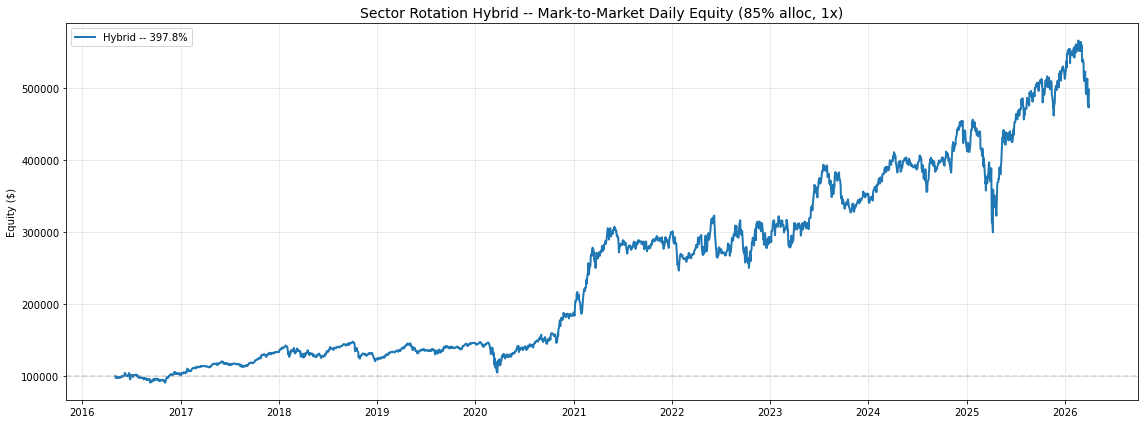

Final equity: $497,797
Total return: 397.8%
Max drawdown: -34.3%

Equal-weight 9-SPDR B&H: 220.3% return, Sharpe 0.76

Delta vs EW benchmark: Sharpe -0.01, Return +177.5pp


In [9]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_eq.index.to_numpy(), daily_eq.values, linewidth=2, color="C0",
        label=f"Hybrid -- {(daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"Sector Rotation Hybrid -- Mark-to-Market Daily Equity "
             f"({BET_SIZE:.0%} alloc, {LEVERAGE}x)", fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

print(f"Final equity: ${daily_eq.iloc[-1]:,.0f}")
print(f"Total return: {(daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}%")
peak = daily_eq.expanding().max()
max_dd = ((daily_eq - peak) / peak).min() * 100
print(f"Max drawdown: {max_dd:.1f}%")

# EW 9-SPDR benchmark
_syms_traded = raw_trades["instrument"].unique().tolist()
ew_ret = pd.DataFrame(index=daily_eq.index)
for sym in _syms_traded:
    ew_ret[sym] = daily_prices_all[sym].reindex(daily_eq.index).ffill().pct_change()
ew_total = ew_ret.mean(axis=1).fillna(0)
ew_eq_curve = STARTING_CAPITAL * (1 + ew_total).cumprod()
ew_sharpe = ew_total.mean() / ew_total.std() * np.sqrt(252) if ew_total.std() > 0 else 0
print(f"\nEqual-weight 9-SPDR B&H: {(ew_eq_curve.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}% "
      f"return, Sharpe {ew_sharpe:.2f}")
print(f"\nDelta vs EW benchmark: "
      f"Sharpe {real_sharpe - ew_sharpe:+.2f}, "
      f"Return {((daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100) - ((ew_eq_curve.iloc[-1]/STARTING_CAPITAL-1)*100):+.1f}pp")


Computing pure momentum benchmark (blend=0.0)...
  Momentum-only: 100 trades
Computing pure regime benchmark (blend=1.0)...
  Regime-only: 2 trades

COMPREHENSIVE BENCHMARK COMPARISON
Strategy                           Sharpe    CAGR%    TotRet%     MaxDD%
----------------------------------------------------------------------------------------
Strategy (Hybrid, full)              0.75    17.57     +397.2      -34.3
Strategy (Hybrid, 2017+)             0.78    18.76     +389.6      -34.3
EW B&H (full)                        0.74    11.05     +182.6      -31.8
EW B&H (2017+)                       0.74    11.02     +162.7      -31.4
Pure Momentum (blend=0)              0.54    11.88     +204.1      -44.6
Pure Regime (blend=1)                0.65    10.54     +170.0      -35.4

KEY DELTAS

Hybrid vs EW B&H (full):    Sharpe +0.01, CAGR +6.51pp, DD -2.5pp
Hybrid vs Pure Momentum:    Sharpe +0.21  <- does regime signal earn its keep?
Hybrid vs Pure Regime:      Sharpe +0.10  <- does momentum

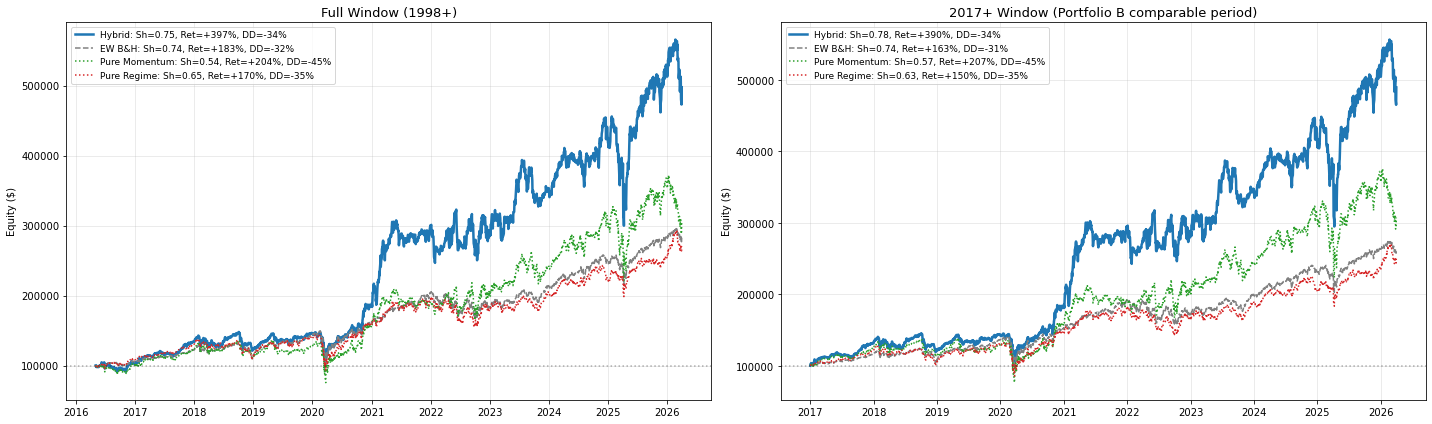


VERDICT
  ==> MARGINAL. Beats momentum but ties EW. Regime signal helps but not enough.


In [12]:
# =============================================================================
# COMPREHENSIVE BENCHMARK COMPARISON
# =============================================================================
# Compares strategy vs:
#   1. EW B&H (true buy-and-hold, 1998+) — initial equal weights, allow drift
#   2. EW B&H (2017+) — same but matches Portfolio B window
#   3. Strategy (2017+) — slice to same 2017 window
#   4. Pure momentum (blend=0.0) — does regime signal add value over momentum alone?

# ── Helper: true buy-and-hold (initial weights, drift) ──
def true_bh_equity(daily_prices_dict, dates, syms, starting_capital=STARTING_CAPITAL,
                    bet_size=BET_SIZE):
    """True buy-and-hold: initial weights, drift; cash portion stays as cash."""
    n_syms = len(syms)
    init_per_sym = (starting_capital * bet_size) / n_syms
    cash_init    = starting_capital * (1 - bet_size)
    
    # Normalize dates to tz-naive
    dates_norm = pd.DatetimeIndex(dates).tz_localize(None) if dates.tz else pd.DatetimeIndex(dates)
    dates_norm = dates_norm.normalize()
    
    px = pd.DataFrame(index=dates_norm)
    for sym in syms:
        s = daily_prices_dict[sym].copy()
        if s.index.tz is not None:
            s.index = s.index.tz_localize(None)
        s.index = s.index.normalize()
        px[sym] = s.reindex(dates_norm).ffill()
    
    # ── KEY FIX: only start the curve from the first day all syms have prices ──
    # Find the first row where all desired sectors have a valid price
    valid_mask = px.notna().all(axis=1)
    if not valid_mask.any():
        # Fallback: use first row that has at least one valid price
        first_partial = px.dropna(how="all").iloc[0] if len(px.dropna(how="all")) > 0 else None
        if first_partial is None:
            return pd.Series(starting_capital, index=dates_norm)
        valid_syms = first_partial.dropna().index.tolist()
        first_prices = first_partial[valid_syms]
    else:
        first_valid_date = px.index[valid_mask][0]
        first_prices = px.loc[first_valid_date]
        valid_syms = syms  # all syms valid by construction
        # Trim to start at first_valid_date
        px = px.loc[first_valid_date:]
    
    shares = pd.Series({s: init_per_sym / first_prices[s] for s in valid_syms})
    
    # Compute sector value WITHOUT filling NaN with 0
    sector_value = px[valid_syms].mul(shares, axis=1).sum(axis=1)
    sector_value = sector_value.ffill()  # only forward-fill; drop leading NaN if any
    
    equity = cash_init + sector_value
    equity = equity.dropna()  # remove any rows that are still NaN
    return equity


# ── Helper: stats for any equity curve ──
def _eq_stats(eq):
    rets = eq.pct_change().dropna()
    sharpe = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0
    total = (eq.iloc[-1] / eq.iloc[0] - 1) * 100
    peak = eq.expanding().max()
    dd = ((eq - peak) / peak).min() * 100
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = ((eq.iloc[-1]/eq.iloc[0]) ** (1/yrs) - 1) * 100 if yrs > 0 else 0
    return {"sharpe": sharpe, "return": total, "dd": dd, "cagr": cagr}


# ── Build benchmarks ──
all_syms = AVAILABLE_ETFS  # all 9 SPDRs

# Strategy curve (already have daily_eq from before)
strat_full = daily_eq.copy()

# Strategy from 2017
START_2017 = pd.Timestamp("2017-01-01")
strat_2017 = strat_full[strat_full.index >= START_2017]
# Re-base to STARTING_CAPITAL on first 2017 day
if len(strat_2017) > 0:
    strat_2017 = strat_2017 / strat_2017.iloc[0] * STARTING_CAPITAL

# EW B&H full window
ew_full = true_bh_equity(daily_prices_all, strat_full.index, all_syms)

# EW B&H from 2017
ew_2017_dates = strat_full.index[strat_full.index >= START_2017]
ew_2017 = true_bh_equity(daily_prices_all, ew_2017_dates, all_syms)

# ── Pure momentum (blend=0.0) — single signal run ──
print("Computing pure momentum benchmark (blend=0.0)...")
momentum_params = {**DEFAULT_PARAMS, "blend": 0.0}
mom_trades = generate_signals(regime_scores, monthly_returns, all_data, **momentum_params)
mom_basket = build_basket_equity(
    mom_trades, daily_prices_all,
    starting_capital=STARTING_CAPITAL, allocation=BET_SIZE)
mom_eq = mom_basket["daily_equity"]
print(f"  Momentum-only: {len(mom_trades)} trades")

# Pure regime (blend=1.0) for completeness
print("Computing pure regime benchmark (blend=1.0)...")
regime_params = {**DEFAULT_PARAMS, "blend": 1.0}
reg_trades = generate_signals(regime_scores, monthly_returns, all_data, **regime_params)
reg_basket = build_basket_equity(
    reg_trades, daily_prices_all,
    starting_capital=STARTING_CAPITAL, allocation=BET_SIZE)
reg_eq = reg_basket["daily_equity"]
print(f"  Regime-only: {len(reg_trades)} trades")

# ── Compute stats ──
results_table = {
    "Strategy (Hybrid, full)": _eq_stats(strat_full),
    "Strategy (Hybrid, 2017+)": _eq_stats(strat_2017) if len(strat_2017) > 0 else None,
    "EW B&H (full)":           _eq_stats(ew_full),
    "EW B&H (2017+)":          _eq_stats(ew_2017) if len(ew_2017) > 0 else None,
    "Pure Momentum (blend=0)":  _eq_stats(mom_eq),
    "Pure Regime (blend=1)":    _eq_stats(reg_eq),
}

# ── Print table ──
print("\n" + "=" * 88)
print("COMPREHENSIVE BENCHMARK COMPARISON")
print("=" * 88)
print(f"{'Strategy':<32} {'Sharpe':>8} {'CAGR%':>8} {'TotRet%':>10} {'MaxDD%':>10}")
print("-" * 88)
for name, s in results_table.items():
    if s is None: continue
    print(f"{name:<32} {s['sharpe']:>8.2f} {s['cagr']:>8.2f} "
          f"{s['return']:>+10.1f} {s['dd']:>+10.1f}")

# Key deltas
print("\n" + "=" * 88)
print("KEY DELTAS")
print("=" * 88)
strat_s = results_table["Strategy (Hybrid, full)"]
ew_s    = results_table["EW B&H (full)"]
mom_s   = results_table["Pure Momentum (blend=0)"]
reg_s   = results_table["Pure Regime (blend=1)"]

print(f"\nHybrid vs EW B&H (full):    Sharpe {strat_s['sharpe']-ew_s['sharpe']:+.2f}, "
      f"CAGR {strat_s['cagr']-ew_s['cagr']:+.2f}pp, DD {strat_s['dd']-ew_s['dd']:+.1f}pp")
print(f"Hybrid vs Pure Momentum:    Sharpe {strat_s['sharpe']-mom_s['sharpe']:+.2f}  "
      f"<- does regime signal earn its keep?")
print(f"Hybrid vs Pure Regime:      Sharpe {strat_s['sharpe']-reg_s['sharpe']:+.2f}  "
      f"<- does momentum earn its keep?")

if results_table["Strategy (Hybrid, 2017+)"] and results_table["EW B&H (2017+)"]:
    s17 = results_table["Strategy (Hybrid, 2017+)"]
    e17 = results_table["EW B&H (2017+)"]
    print(f"\n2017+ window: Hybrid Sharpe {s17['sharpe']:.2f} vs EW {e17['sharpe']:.2f} "
          f"(delta {s17['sharpe']-e17['sharpe']:+.2f})")

# ── Side-by-side plot: full window vs 2017+ ──
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Full window
ax = axes[0]
for name, eq, color, lw, ls in [
    ("Hybrid",         strat_full, "C0",   2.5, "-"),
    ("EW B&H",         ew_full,    "gray", 1.5, "--"),
    ("Pure Momentum",  mom_eq,     "C2",   1.5, ":"),
    ("Pure Regime",    reg_eq,     "C3",   1.5, ":"),
]:
    s = _eq_stats(eq)
    ax.plot(eq.index.to_numpy(), eq.values, color=color, linewidth=lw, linestyle=ls,
            label=f"{name}: Sh={s['sharpe']:.2f}, Ret={s['return']:+.0f}%, DD={s['dd']:.0f}%")
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_title("Full Window (1998+)", fontsize=13)
ax.set_ylabel("Equity ($)"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 2017+ window
ax = axes[1]
if len(strat_2017) > 0 and len(ew_2017) > 0:
    mom_2017 = mom_eq[mom_eq.index >= START_2017]
    if len(mom_2017) > 0:
        mom_2017 = mom_2017 / mom_2017.iloc[0] * STARTING_CAPITAL
    reg_2017 = reg_eq[reg_eq.index >= START_2017]
    if len(reg_2017) > 0:
        reg_2017 = reg_2017 / reg_2017.iloc[0] * STARTING_CAPITAL
    
    for name, eq, color, lw, ls in [
        ("Hybrid",         strat_2017, "C0",   2.5, "-"),
        ("EW B&H",         ew_2017,    "gray", 1.5, "--"),
        ("Pure Momentum",  mom_2017,   "C2",   1.5, ":"),
        ("Pure Regime",    reg_2017,   "C3",   1.5, ":"),
    ]:
        s = _eq_stats(eq)
        ax.plot(eq.index.to_numpy(), eq.values, color=color, linewidth=lw, linestyle=ls,
                label=f"{name}: Sh={s['sharpe']:.2f}, Ret={s['return']:+.0f}%, DD={s['dd']:.0f}%")
    ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
    ax.set_title("2017+ Window (Portfolio B comparable period)", fontsize=13)
    ax.set_ylabel("Equity ($)"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ── Verdict ──
print("\n" + "=" * 70)
print("VERDICT")
print("=" * 70)
gap_vs_mom = strat_s["sharpe"] - mom_s["sharpe"]
gap_vs_ew  = strat_s["sharpe"] - ew_s["sharpe"]

if gap_vs_mom >= 0.05 and gap_vs_ew >= 0.05:
    print("  ==> KEEP. Hybrid beats both pure momentum AND EW benchmark.")
elif gap_vs_mom >= 0.05:
    print("  ==> MARGINAL. Beats momentum but ties EW. Regime signal helps but not enough.")
elif gap_vs_ew >= 0.05:
    print("  ==> ODD. Beats EW but not momentum -- maybe just lucky concentration.")
else:
    print("  ==> ARCHIVE. Hybrid does not beat the simpler alternatives on Sharpe.")
    print("      The regime signal does not add risk-adjusted value beyond pure momentum.")

## 7. Per-Sector Breakdown

In [14]:
print(f"{'ETF':<6} {'Trades':>8} {'WR %':>7} {'Avg Ret %':>11} {'Total %':>10} {'Avg Hold':>10}")
print("-" * 60)
for sym in sorted(raw_trades["instrument"].unique()):
    subset = raw_trades[raw_trades["instrument"] == sym]
    if subset.empty:
        continue
    n = len(subset)
    wins = (subset["pct_return_gross"] > 0).sum()
    avg_ret = subset["pct_return_gross"].mean() * 100
    total_ret = ((1 + subset["pct_return_gross"]).prod() - 1) * 100
    avg_hold = (subset["exit_time"] - subset["entry_time"]).dt.days.mean()
    print(f"{sym:<6} {n:>8} {wins/n*100:>6.1f}  {avg_ret:>+10.3f}  {total_ret:>+9.1f}  {avg_hold:>9.1f}d")

print("\n" + "=" * 60)
print("EXIT REASON ANALYSIS")
print("=" * 60)
for reason in raw_trades["exit_reason"].unique():
    subset = raw_trades[raw_trades["exit_reason"] == reason]
    avg_ret = subset["pct_return_gross"].mean() * 100
    avg_hold = (subset["exit_time"] - subset["entry_time"]).dt.days.mean()
    wins = (subset["pct_return_gross"] > 0).sum()
    print(f"  {reason:<15} n={len(subset):3d}, WR={wins/len(subset)*100:.0f}%, "
          f"avg return: {avg_ret:+.2f}%, avg hold: {avg_hold:.0f}d")


ETF      Trades    WR %   Avg Ret %    Total %   Avg Hold
------------------------------------------------------------
XLB          16   50.0      +1.410      +20.6       64.7d
XLE          11   45.5      +1.803      +14.8       49.9d
XLF           7   71.4      +3.405      +25.6       30.3d
XLI          18   72.2      +3.433      +74.0       87.1d
XLK          14   78.6      +3.865      +65.3       71.6d
XLP           6   66.7      +1.401       +8.5       45.7d
XLU          14   64.3      +0.041       -2.8       70.2d
XLV           7   85.7      +2.570      +19.2       52.3d
XLY          15   66.7      +2.879      +48.3       83.4d

EXIT REASON ANALYSIS
  rotation_out    n=106, WR=65%, avg return: +2.15%, avg hold: 59d
  end_of_data     n=  2, WR=100%, avg return: +12.43%, avg hold: 500d


## 8. Concurrency & Cohort Analysis

ACTIVE-ETF COUNT DISTRIBUTION
  Days active: 2587 / 2587
  Avg ETFs held when active: 2.04

SECTOR HOLDING FREQUENCY
  XLI    44.0%  ######################
  XLY    34.9%  #################
  XLB    29.3%  ##############
  XLK    28.4%  ##############
  XLU    27.6%  #############
  XLE    15.6%  #######
  XLV    10.3%  #####
  XLP     7.8%  ###
  XLF     6.1%  ###

TURNOVER
  Avg ETFs entering per rebalance: 1.30
  Avg ETFs exiting per rebalance:  1.30
  Total rebalance dates:            83


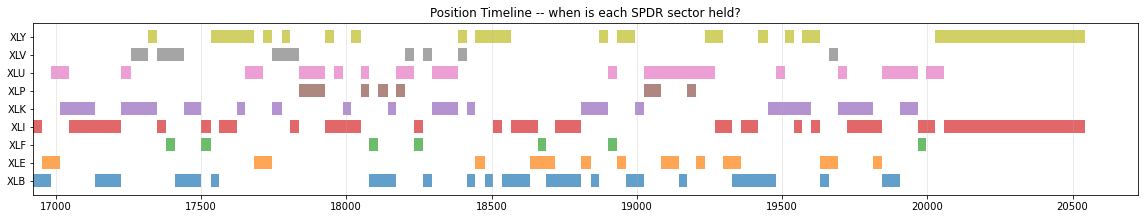

In [15]:
all_dates = pd.date_range(
    raw_trades["entry_time"].min(),
    raw_trades["exit_time"].max(),
    freq="B",
)
syms_traded = sorted(raw_trades["instrument"].unique())
in_pos = pd.DataFrame(0, index=all_dates, columns=syms_traded)

for _, t in raw_trades.iterrows():
    sym = t["instrument"]
    mask = (in_pos.index >= t["entry_time"]) & (in_pos.index <= t["exit_time"])
    in_pos.loc[mask, sym] = 1

print("=" * 70)
print("ACTIVE-ETF COUNT DISTRIBUTION")
print("=" * 70)
active_counts = in_pos.sum(axis=1)
print(f"  Days active: {(active_counts > 0).sum()} / {len(active_counts)}")
print(f"  Avg ETFs held when active: {active_counts[active_counts > 0].mean():.2f}")

print("\n" + "=" * 70)
print("SECTOR HOLDING FREQUENCY")
print("=" * 70)
active_days = in_pos.sum(axis=1) > 0
active_slice = in_pos.loc[active_days]
freq = (active_slice.sum(axis=0) / len(active_slice) * 100).sort_values(ascending=False)
for sym, pct in freq.items():
    bar = "#" * int(pct / 2)
    print(f"  {sym:<5} {pct:>5.1f}%  {bar}")

print("\n" + "=" * 70)
print("TURNOVER")
print("=" * 70)
entries_by_date = raw_trades.groupby(raw_trades["entry_time"].dt.normalize()).size()
exits_by_date   = raw_trades.groupby(raw_trades["exit_time"].dt.normalize()).size()
print(f"  Avg ETFs entering per rebalance: {entries_by_date.mean():.2f}")
print(f"  Avg ETFs exiting per rebalance:  {exits_by_date.mean():.2f}")
print(f"  Total rebalance dates:            {len(entries_by_date)}")

fig, ax = plt.subplots(figsize=(16, max(3, len(syms_traded) * 0.35)))
for i, sym in enumerate(syms_traded):
    sym_trades = raw_trades[raw_trades["instrument"] == sym]
    for _, t in sym_trades.iterrows():
        ax.barh(i, (t["exit_time"] - t["entry_time"]).days,
                left=t["entry_time"], height=0.7, color=f"C{i % 10}", alpha=0.7)
ax.set_yticks(range(len(syms_traded)))
ax.set_yticklabels(syms_traded)
ax.set_title("Position Timeline -- when is each SPDR sector held?")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout(); plt.show()


## 9. Save Standardized Trades

In [16]:
import os, json

os.makedirs("results", exist_ok=True)

std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
raw_trades[std_cols].to_csv(f"results/{SAVE_NAME}_trades.csv", index=False)
print(f"Saved {len(raw_trades)} standardized trades -> results/{SAVE_NAME}_trades.csv")

summary = {
    "strategy":    STRATEGY_NAME,
    "instruments": ETFS,
    "portfolio":   "long_term",
    "trade_period": f"{TRADE_START} -> {TRADE_END}",
    "regime_scores_source": REGIME_SCORES_PATH,
    "params":      {k: v for k, v in DEFAULT_PARAMS.items()},
    "trades":      len(raw_trades),
    "has_stop":    False,
    "architecture": "basket",
    "significance": {
        "gross": {"sharpe": report_gross["bootstrap"]["observed_sharpe"],
                  "verdict": report_gross["verdict"],
                  "tests_passed": report_gross["tests_passed"]},
        "net":   {"sharpe": report_net["bootstrap"]["observed_sharpe"],
                  "verdict": report_net["verdict"],
                  "tests_passed": report_net["tests_passed"]},
    },
}
with open(f"results/{SAVE_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"Saved summary -> results/{SAVE_NAME}_summary.json")
print(f"\nNext: run Sector_Rotation_Hybrid_Implementation.ipynb for sizing comparison")


Saved 108 standardized trades -> results/sector_rotation_hybrid_trades.csv
Saved summary -> results/sector_rotation_hybrid_summary.json

Next: run Sector_Rotation_Hybrid_Implementation.ipynb for sizing comparison
